# Integrating scDNA and scRNA with clonealign

Runs the real **[`clonealign`](https://github.com/kieranrcampbell/clonealign)** (Campbell et al. 2019)
on data simulated by `iscc`, and scores its clone assignments against ground truth the tool never
sees.

**R notebook**, kernel `R (iscc-clonealign)` — the code below is the R you would write yourself, not
a Python wrapper. It contains no simulation; the dataset was generated once by
`python validation/make_analysis_data.py --only clonealign`:

| file | what it is | who sees it |
|---|---|---|
| `Y.csv.gz` | scRNA counts, cells × genes | the tool |
| `L.csv.gz` | copy number, genes × clones | the tool |
| `truth.csv` | each cell's true clone | **scoring only** |

**What this shows.** `clonealign` assigns single cells to copy-number clones by assuming a gene's
expression scales with the number of copies its clone carries. The question here is whether `iscc`'s
simulated expression carries that dosage relationship faithfully enough for the real tool to exploit
it — i.e. whether simulated data is *amenable to the analysis a real study would run*.

**The tumour.** A realistic breach-gated ductal field (grid 96, 5 glands, 6,000 genes), WGD+, with
four subclones distinguished across 11 of its 12 segments. Note that not every simulated tumour is
like this: subclones can also end up near-identical in copy number, and a dosage model then has very
little to separate them — that case is measured in the validation suite rather than here.

In [1]:
# reticulate must be pointed at THIS env's Python, or it searches a cached uv interpreter and
# reports "Valid installation of TensorFlow not found" — clonealign's backend is TensorFlow via
# reticulate, so this preamble is load-bearing, not boilerplate.
local({
  env_py <- file.path(dirname(dirname(R.home())), "bin", "python")
  if (file.exists(env_py)) Sys.setenv(RETICULATE_PYTHON = env_py)
})

suppressWarnings(suppressMessages({
  library(clonealign)
  library(tensorflow)
  library(jsonlite)
}))

data_dir <- file.path("..", "analysis_data", "clonealign")
stopifnot(dir.exists(data_dir))

Y <- as.matrix(read.csv(file.path(data_dir, "Y.csv.gz"), row.names = 1, check.names = FALSE))
L <- as.matrix(read.csv(file.path(data_dir, "L.csv.gz"), row.names = 1, check.names = FALSE))
meta <- fromJSON(file.path(data_dir, "meta.json"))

cat(sprintf("Y: %d cells x %d genes\nL: %d genes x %d clones\n",
            nrow(Y), ncol(Y), nrow(L), ncol(L)))
cat(sprintf("clone sizes: %s\n", paste(meta$clone_sizes, collapse = ", ")))
cat(sprintf("baselines — chance %.2f, majority %.2f\n",
            meta$chance_baseline, meta$majority_baseline))
cat("\nclone copy-number consensus (rows = clones, cols = segments):\n")
print(meta$cn_consensus)

Y: 1501 cells x 6000 genes
L: 6000 genes x 4 clones


clone sizes: 575, 730, 87, 109


baselines — chance 0.25, majority 0.49



clone copy-number consensus (rows = clones, cols = segments):


     [,1] [,2] [,3] [,4] [,5] [,6] [,7] [,8] [,9] [,10] [,11] [,12]
[1,]    4    4    2    4    2    4    3    4    2     2     4     4
[2,]    4    4    2    4    2    4    4    4    2     2     4     4
[3,]    4    4    2    5    2    4    3    5    2     2     2     4
[4,]    2    2    1    2    1    3    2    2    2     1     1     2


## What to expect

The clones differ across 11 of the 12 segments, so most of the 6,000 genes sit on a segment whose
copy number varies between clones — real dosage signal for the model to use.

Two baselines matter when reading the score. **Chance** is 1/4 = 0.25. The **majority** baseline —
always guessing the biggest clone — is 0.49 here, and that is the bar a useful method must clear.
Accuracy alone can flatter or libel a method under class imbalance, so ARI and one-vs-rest AUC are
reported beside it.

In [2]:
# Align genes across the two modalities, then fit.
common <- intersect(colnames(Y), rownames(L))
Yc <- Y[, common, drop = FALSE]; storage.mode(Yc) <- "double"
Lc <- L[common, , drop = FALSE]; storage.mode(Lc) <- "double"

set.seed(1); tf$compat$v1$set_random_seed(1L)

# clonealign's own multi-restart wrapper. The variational objective is sensitive to initialisation,
# so a single fit can settle in a poor local optimum; this is the package's intended entry point.
fit <- run_clonealign(Yc, Lc,
                      initial_shrinks = c(0, 5, 10),
                      n_repeats = 3,
                      max_iter = 200,
                      print_elbos = FALSE,
                      verbose = FALSE)

probs <- fit$ml_params$clone_probs
colnames(probs) <- colnames(Lc); rownames(probs) <- rownames(Yc)
cat(sprintf("fitted: %d cells assigned over %d clones\n", nrow(probs), ncol(probs)))
table(fit$clone)

Warning message in (function (gene_expression_data, copy_number_data, max_iter = 200, :
“Less than 75% of genes positively correlated with expression - assignment may have failed
”


Warning message in (function (gene_expression_data, copy_number_data, max_iter = 200, :
“Less than 75% of genes positively correlated with expression - assignment may have failed
”


Warning message in (function (gene_expression_data, copy_number_data, max_iter = 200, :
“Less than 75% of genes positively correlated with expression - assignment may have failed
”


Warning message in (function (gene_expression_data, copy_number_data, max_iter = 200, :
“Less than 75% of genes positively correlated with expression - assignment may have failed
”


Warning message in (function (gene_expression_data, copy_number_data, max_iter = 200, :
“Less than 75% of genes positively correlated with expression - assignment may have failed
”


...

Warning message in (function (gene_expression_data, copy_number_data, max_iter = 200, :
“Less than 75% of genes positively correlated with expression - assignment may have failed
”


Warning message in (function (gene_expression_data, copy_number_data, max_iter = 200, :
“Less than 75% of genes positively correlated with expression - assignment may have failed
”


Warning message in (function (gene_expression_data, copy_number_data, max_iter = 200, :
“Less than 75% of genes positively correlated with expression - assignment may have failed
”


fitted: 1501 cells assigned over 4 clones



    clone0     clone1     clone2     clone3 unassigned 
       437        626        105        105        228 

## Scoring against ground truth

Only now do we open `truth.csv`. Predicted clone labels are arbitrary, so we take the best
permutation of predicted-to-true labels (with three clones there are only six, so we enumerate them
rather than reaching for the Hungarian algorithm).

In [3]:
truth <- read.csv(file.path(data_dir, "truth.csv"), stringsAsFactors = FALSE)
true_clone <- truth$true_clone[match(rownames(probs), truth$cell)]
pred <- max.col(probs) - 1L                      # 0-based, to match the truth file

# best label permutation (3 clones -> 6 permutations, so enumerate rather than use Hungarian)
K <- ncol(probs)
perms <- as.matrix(expand.grid(rep(list(0:(K - 1)), K)))
perms <- perms[apply(perms, 1, function(r) length(unique(r)) == K), , drop = FALSE]
best <- which.max(apply(perms, 1, function(p) mean(p[pred + 1L] == true_clone)))
acc  <- mean(perms[best, ][pred + 1L] == true_clone)
maj  <- max(table(true_clone)) / length(true_clone)

# ACCURACY ALONE IS MISLEADING HERE: the clones are 1062/211/254, so "always guess the biggest"
# already scores ~0.70. Rank-based measures say whether the tool found signal at all, independent
# of that imbalance.
adj_rand <- function(a, b) {                     # adjusted Rand index, from the contingency table
  tab <- table(a, b); n <- length(a)
  ch2 <- function(x) sum(x * (x - 1) / 2)
  idx <- ch2(tab); ea <- ch2(rowSums(tab)); eb <- ch2(colSums(tab)); tot <- n * (n - 1) / 2
  (idx - ea * eb / tot) / (0.5 * (ea + eb) - ea * eb / tot)
}
auc1 <- function(score, pos) {                   # one-vs-rest AUC (Mann-Whitney)
  r <- rank(score); np <- sum(pos); nn <- sum(!pos)
  if (np == 0 || nn == 0) return(NA_real_)
  (sum(r[pos]) - np * (np + 1) / 2) / (np * nn)
}
mapped_true <- match(true_clone, perms[best, ]) - 1L   # true labels in predicted-column space
aucs <- sapply(seq_len(K), function(k) auc1(probs[, k], mapped_true == (k - 1L)))

cat("clonealign vs iscc ground truth\n")
cat(sprintf("  accuracy %.2f   (chance %.2f, majority %.2f)  -> %s the majority baseline\n",
            acc, 1 / K, maj, ifelse(acc > maj + 0.02, "ABOVE", "AT OR BELOW")))
cat(sprintf("  ARI      %.2f   (0 = no better than random grouping)\n", adj_rand(pred, true_clone)))
cat(sprintf("  mean AUC %.2f   per clone: %s\n", mean(aucs, na.rm = TRUE),
            paste(sprintf("%.2f", aucs), collapse = ", ")))
# Make the verdict follow the numbers rather than hard-coding a conclusion: a hard-coded closing
# sentence silently goes stale the moment the dataset changes.
if (acc > maj + 0.02) {
  cat(sprintf("\n  Above the majority baseline on hard assignment, with mean AUC %.2f: iscc's simulated\n", mean(aucs, na.rm = TRUE)))
  cat("  expression carries the copy-number dosage signal clonealign relies on.\n")
} else {
  cat(sprintf("\n  AUC %.2f above 0.5 with accuracy at the majority baseline: signal was found, but not\n", mean(aucs, na.rm = TRUE)))
  cat("  enough to win hard assignments against the largest clone.\n")
}

clonealign vs iscc ground truth


  accuracy 0.81   (chance 0.25, majority 0.49)  -> ABOVE the majority baseline


  ARI      0.47   (0 = no better than random grouping)


  mean AUC 0.94   per clone: 0.88, 0.90, 1.00, 0.99



  Above the majority baseline on hard assignment, with mean AUC 0.94: iscc's simulated
  expression carries the copy-number dosage signal clonealign relies on.


## Reading the result

If the accuracy sits at the majority baseline, `clonealign` has not found the clone structure — and
on this tumour that is the expected outcome rather than a failure of the tool. Copy-number dosage is
almost uninformative when clones share copy number in ten of twelve segments.

The companion notebook `combining_scdna_scrna.ipynb` shows what *does* separate these clones: the
**allele** layer. Two clones can both sit at total copy number 4 while differing in their allelic
composition (4+0 versus 2+2), and B-allele frequency sees a difference that total copy number cannot.

That contrast is the point. A benchmark on a substrate where every tool succeeds tells you nothing
about which modality carries the signal.

## What the assignment looks like

`clonealign`'s own `plot_clonealign` needs a `SingleCellExperiment`, which this environment does not
carry, so these are drawn with ggplot2 from the fit itself. Left: where each cell was assigned against
its true clone. Right: the model's confidence in its own call, split by whether that call was right —
a well-behaved fit should be confident when correct and hesitant when not.

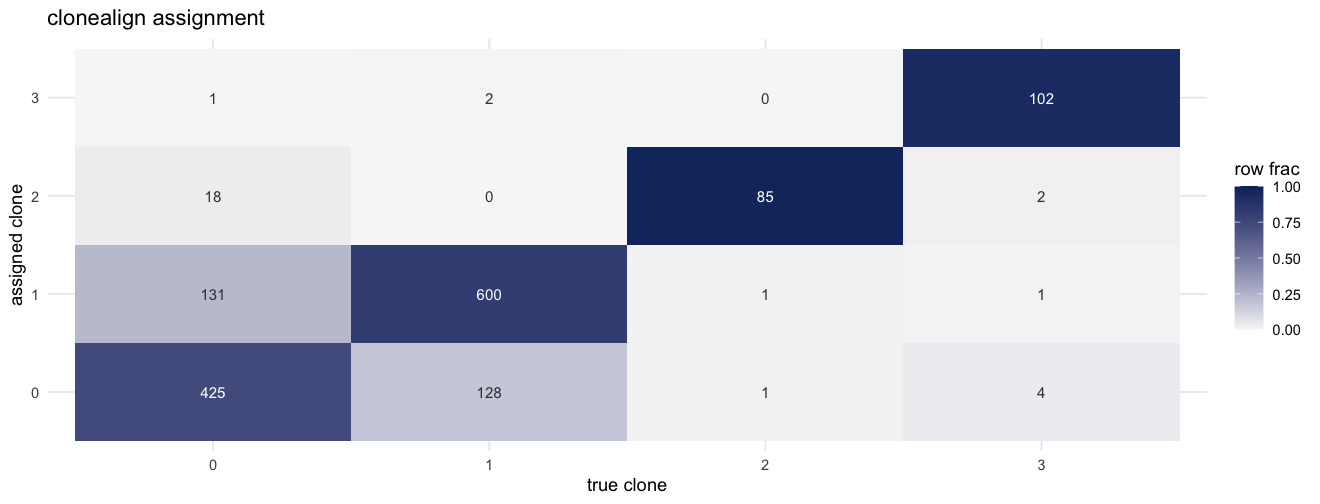

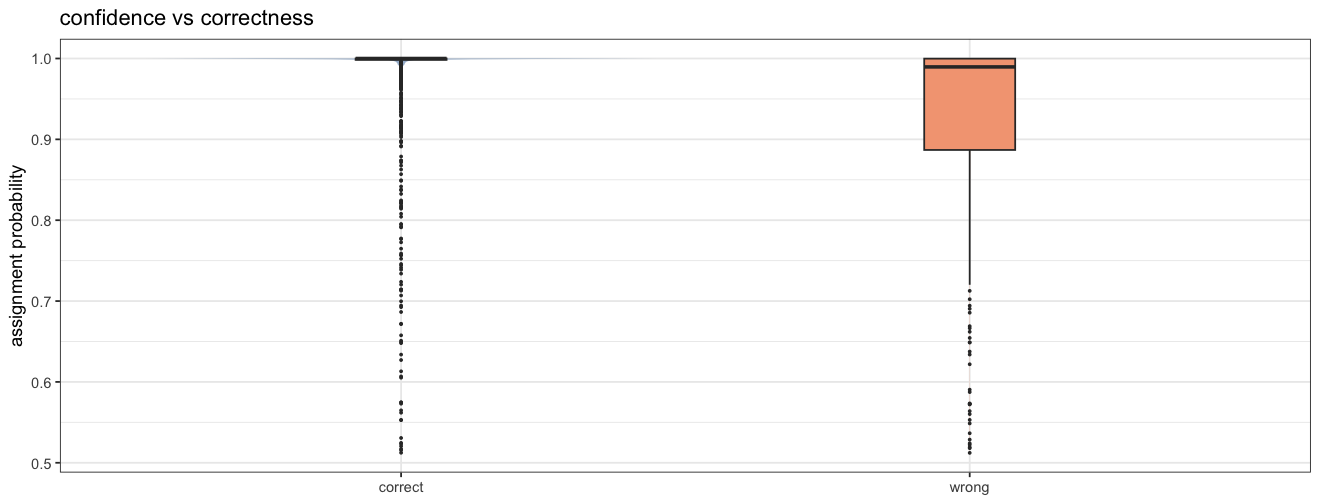

In [4]:
suppressMessages(library(ggplot2))
mapped <- perms[best, ][pred + 1L]
conf <- as.data.frame(table(true = true_clone, assigned = mapped))
conf$frac <- conf$Freq / ave(conf$Freq, conf$true, FUN = sum)

options(repr.plot.width = 11, repr.plot.height = 4.2)
p1 <- ggplot(conf, aes(factor(true), factor(assigned), fill = frac)) +
  geom_tile() + geom_text(aes(label = Freq), size = 3.2,
                          colour = ifelse(conf$frac > .5, "white", "grey25")) +
  scale_fill_gradient(low = "#f7f7f7", high = "#08306b", limits = c(0, 1), name = "row frac") +
  labs(x = "true clone", y = "assigned clone", title = "clonealign assignment") +
  theme_minimal(base_size = 11)

d2 <- data.frame(conf_cell = apply(probs, 1, max),
                 correct = ifelse(mapped == true_clone, "correct", "wrong"))
p2 <- ggplot(d2, aes(correct, conf_cell, fill = correct)) +
  geom_violin(alpha = .55, colour = NA) + geom_boxplot(width = .16, outlier.size = .4) +
  scale_fill_manual(values = c(correct = "#4c78a8", wrong = "#f4a582"), guide = "none") +
  labs(x = NULL, y = "assignment probability", title = "confidence vs correctness") +
  theme_bw(base_size = 11)
print(p1); print(p2)